# Experiment 14: Comprehensive Linear Regression Modeling and Error Diagnostics

**AIM:**  
To build and diagnose a Linear Regression model predicting `BMI` from `Glucose` with train-test validation, computing complete error metrics ($R^2$, MSE, RMSE, MAE) and analyzing residual distributions.

**SOFTWARE REQUIREMENTS:**  
- **Python**: Version 3.13.x  
- **Jupyter Notebook**: Version 7.x  
- **Packages**: NumPy, Pandas, Scikit-Learn, Matplotlib, Seaborn  

---
### THEORY:
- **Regression Diagnostics & Residuals**: Residuals $e_i = y_i - \hat{y}_i$ represent unexplained variance. Valid linear models should have zero-mean, normally distributed homoscedastic errors.
- **Error Metrics**:
  - **Mean Squared Error (MSE)**: $\frac{1}{n} \sum (y_i - \hat{y}_i)^2$
  - **Root Mean Squared Error (RMSE)**: $\sqrt{\text{MSE}}$
  - **Mean Absolute Error (MAE)**: $\frac{1}{n} \sum |y_i - \hat{y}_i|$
  - **$R^2$ Score**: $1 - \frac{SS_{res}}{SS_{tot}}$

---
### PROCEDURE:
1. Load diabetes dataset and split into 80% train and 20% test sets.
2. Fit `LinearRegression` model using `Glucose` as predictor and `BMI` as target.
3. Compute predictions on the unseen test set.
4. Calculate $R^2$, MSE, RMSE, and MAE error statistics.
5. Plot regression line fit and residual error distribution charts.

## 1. Import Libraries & Fit Linear Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pima_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_diabetes = pd.read_csv('pima_diabetes.csv', header=None, names=pima_columns)

X = pima_diabetes[['Glucose']]
y = pima_diabetes['BMI']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)
residuals = y_test - y_pred

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print('Pima Indians Diabetes - Linear Regression Diagnostics (Glucose -> BMI):')
print(f'R2 Score: {r2:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')

Pima Indians Diabetes - Linear Regression Diagnostics (Glucose -> BMI):
R2 Score: 0.0698
Mean Squared Error (MSE): 66.1202
Root Mean Squared Error (RMSE): 8.1314
Mean Absolute Error (MAE): 5.8660


## 2. Regression Fit and Residual Diagnostics Plots

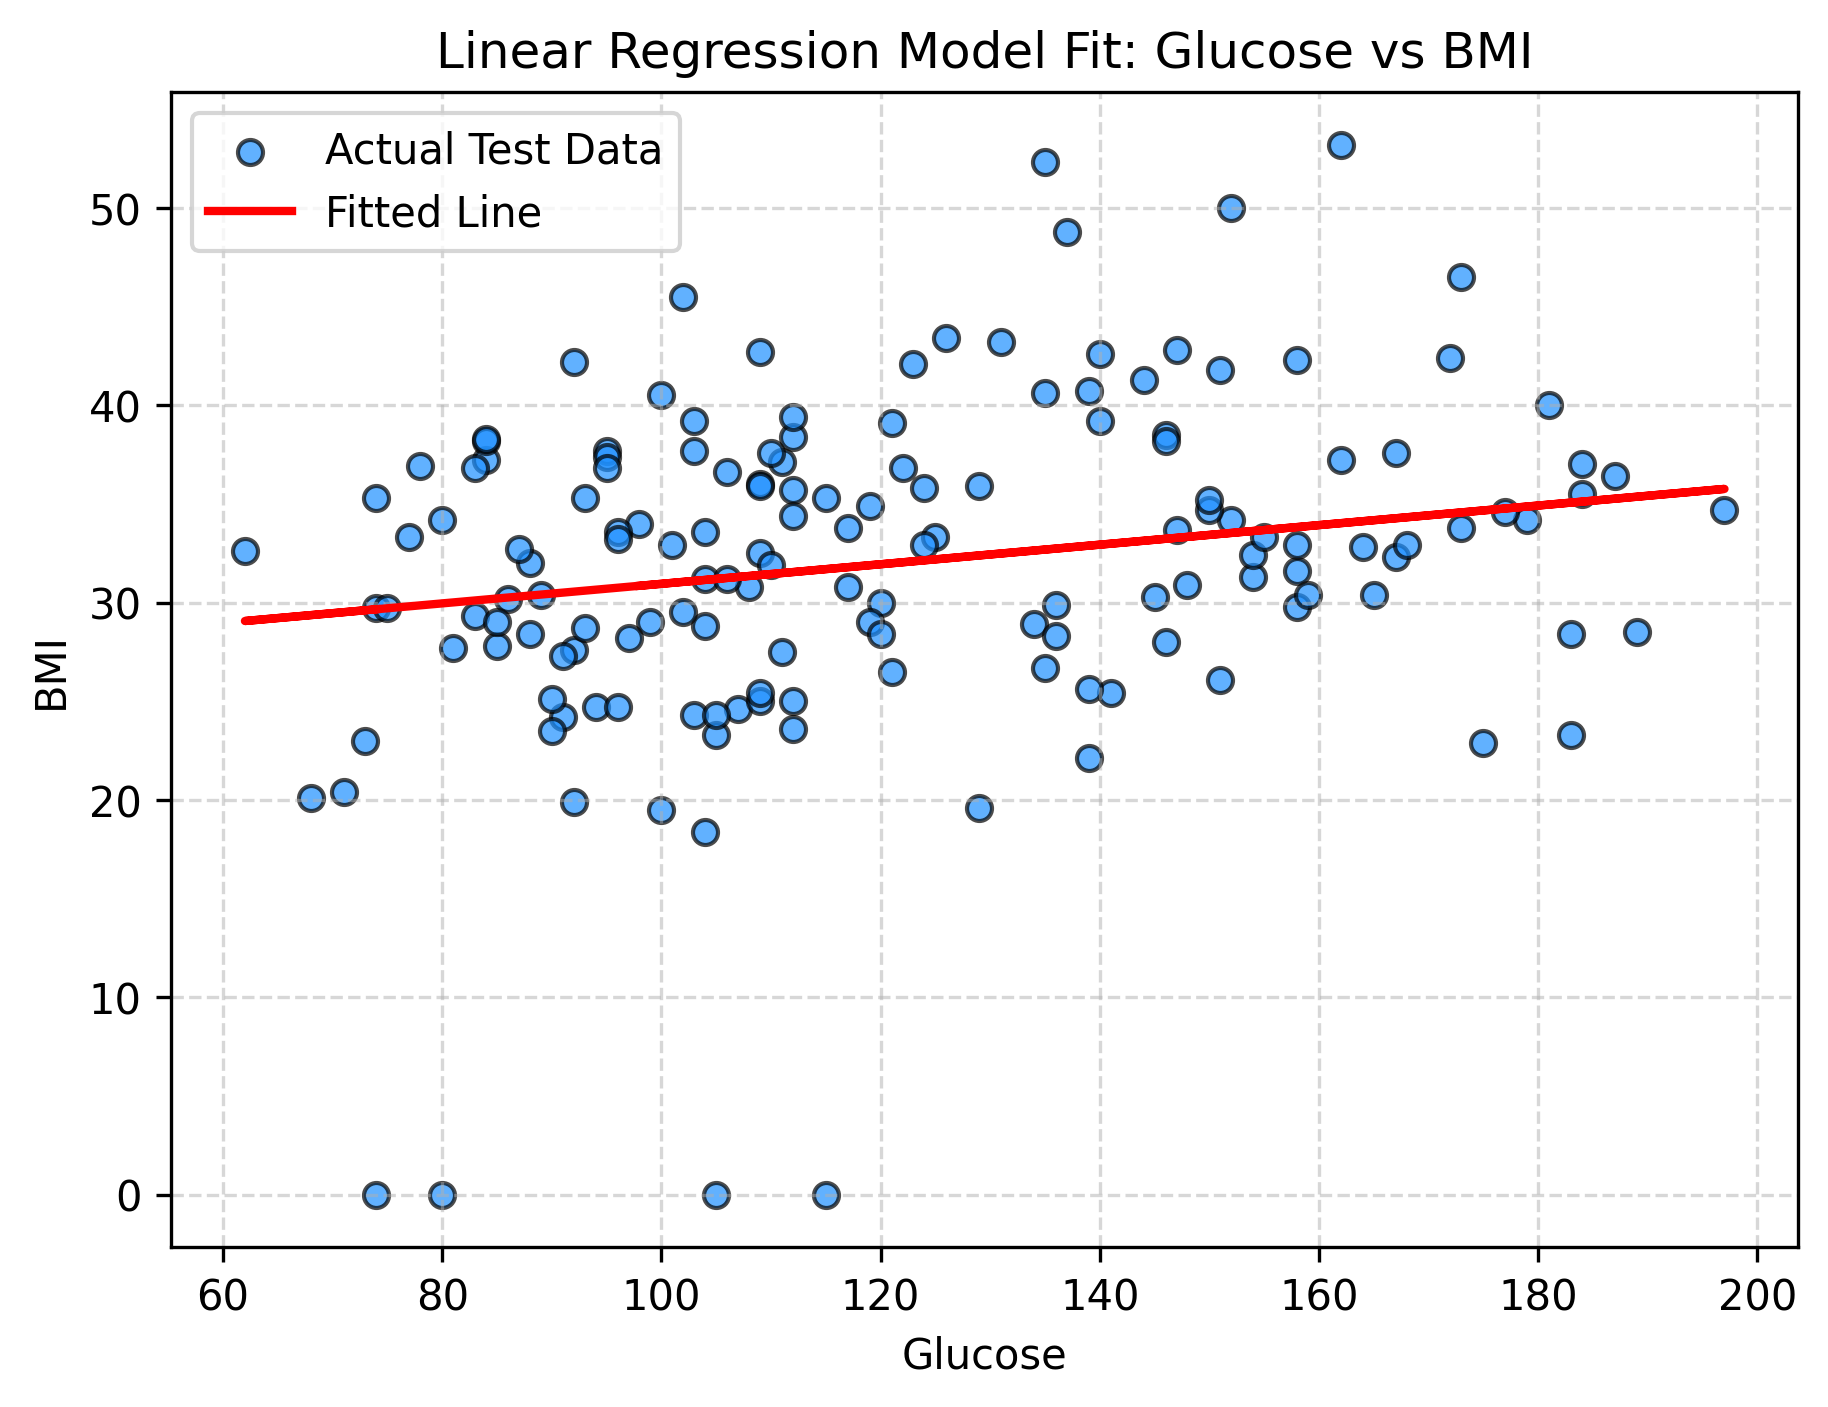

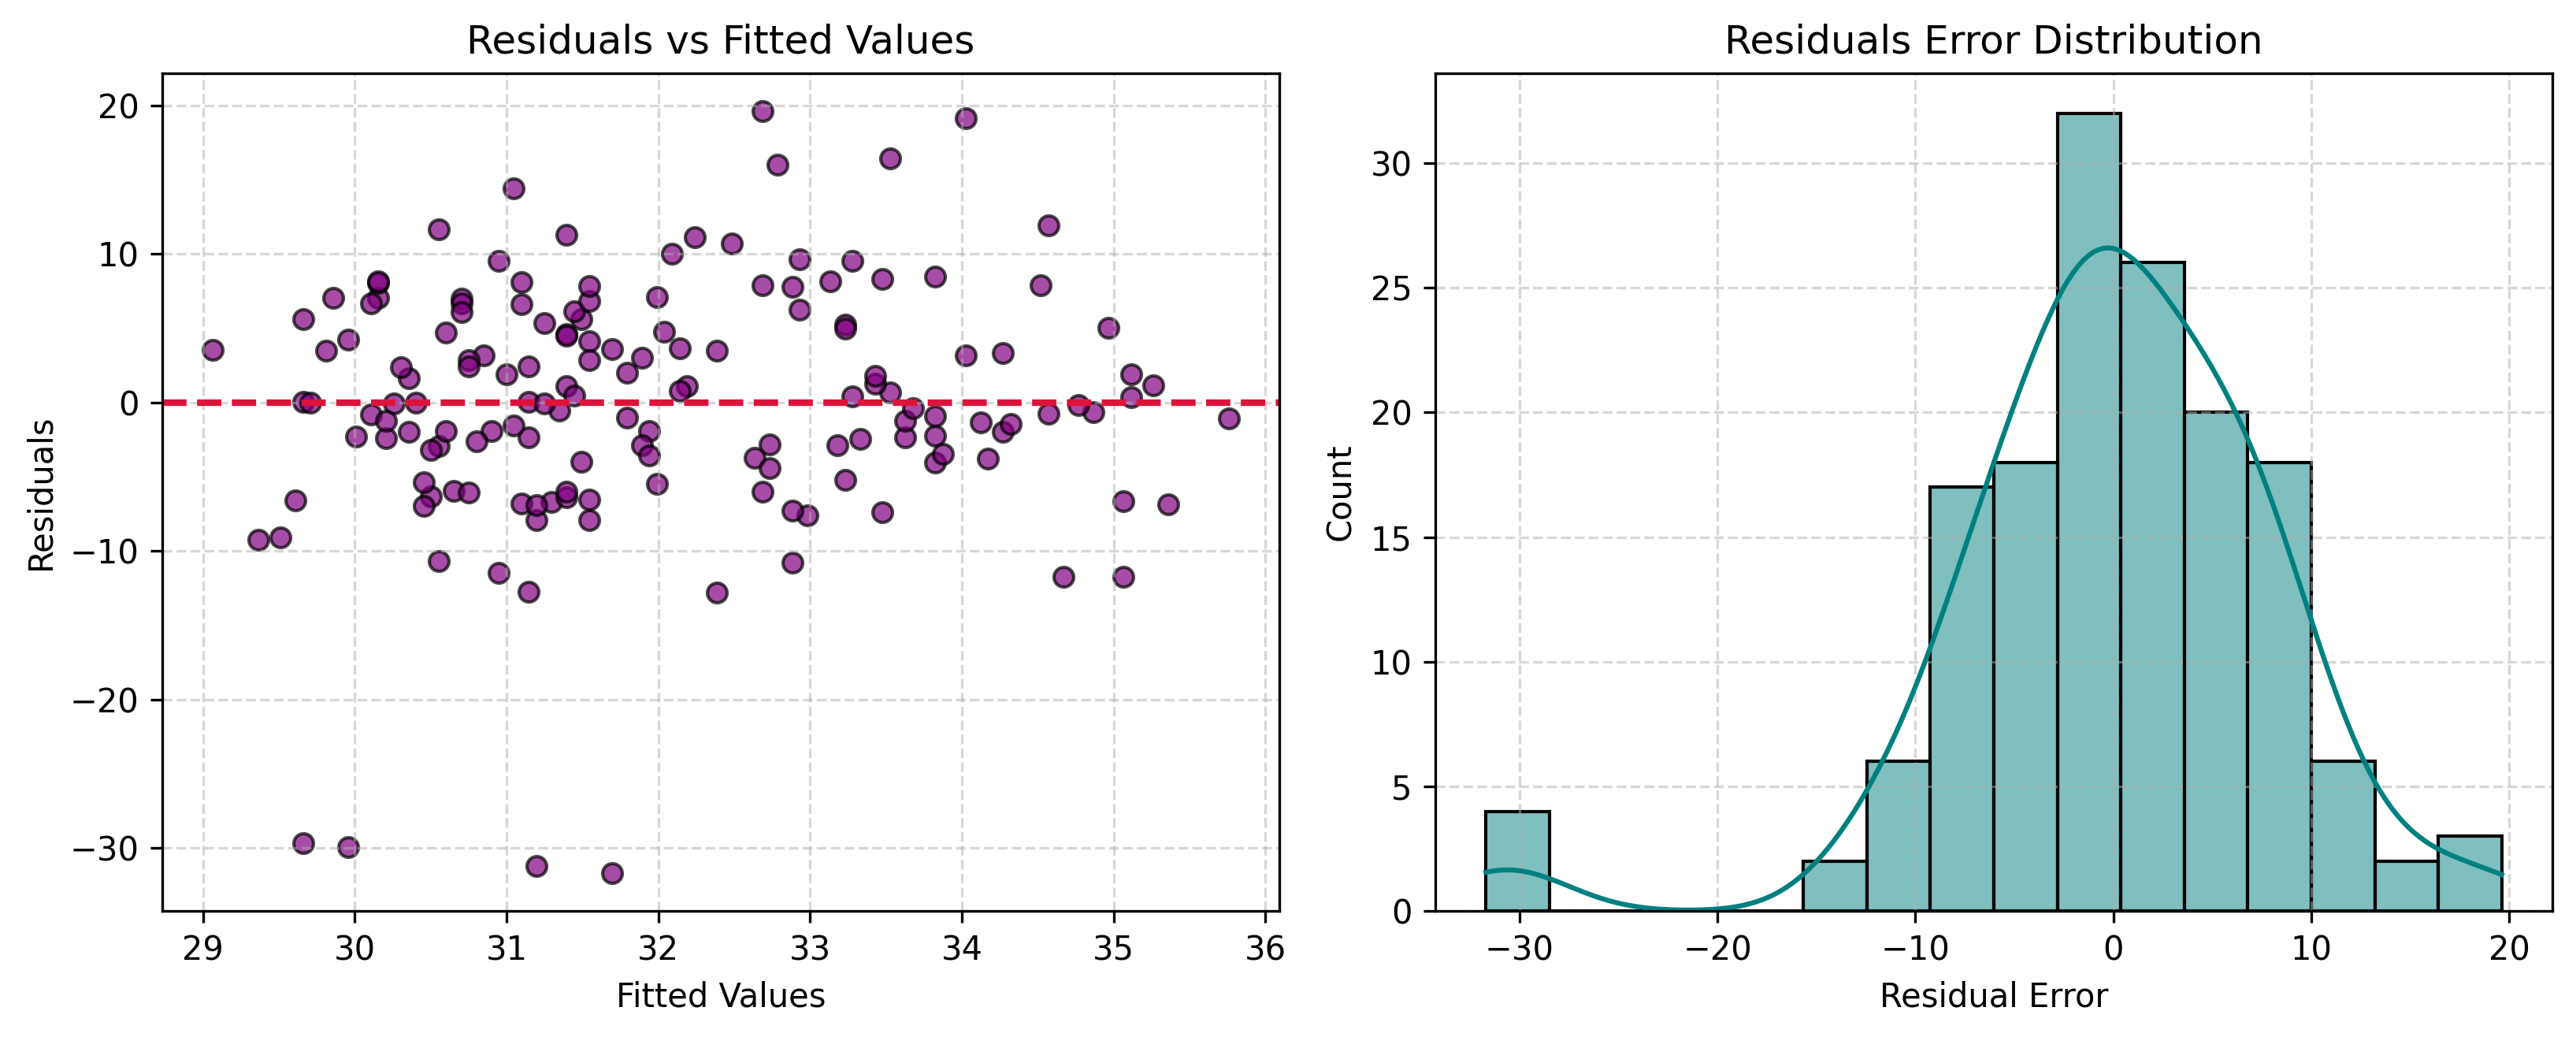

In [2]:
plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, color='dodgerblue', alpha=0.7, edgecolors='k', label='Actual Test Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Fitted Line')
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Linear Regression Model Fit: Glucose vs BMI')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(y_pred, residuals, color='purple', alpha=0.7, edgecolors='k')
axes[0].axhline(0, color='crimson', linestyle='--', lw=2)
axes[0].set_title('Residuals vs Fitted Values')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.histplot(residuals, kde=True, ax=axes[1], color='teal', edgecolor='k')
axes[1].set_title('Residuals Error Distribution')
axes[1].set_xlabel('Residual Error')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()